# Visión Computacional (OpenCV)
**Misión:** Procesamiento de imágenes para extracción de Regiones de Interés (ROI), segmentación HSV y cálculo de error espacial.

Este notebook valida la lógica de visión de forma estática utilizando un dataset de prueba capturado desde el entorno virtual, aislando el comportamiento de los algoritmos de detección antes de su integración en el nodo ROS2.

In [15]:
!unzip Dataset_robot_verde.zip

Archive:  Dataset_robot_verde.zip
   creating: Dataset_robot_verde/
  inflating: Dataset_robot_verde/verde_01.jpeg  
  inflating: Dataset_robot_verde/verde_02.jpeg  
  inflating: Dataset_robot_verde/verde_03.jpeg  
  inflating: Dataset_robot_verde/verde_04.jpeg  
  inflating: Dataset_robot_verde/verde_05.jpeg  
  inflating: Dataset_robot_verde/verde_06.jpeg  
  inflating: Dataset_robot_verde/verde_07.jpeg  
  inflating: Dataset_robot_verde/verde_08.jpeg  
  inflating: Dataset_robot_verde/verde_09.jpeg  
  inflating: Dataset_robot_verde/verde_10.jpeg  


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

# Configuración para mostrar los gráficos de matplotlib directamente en el notebook
%matplotlib inline

In [23]:
def procesar_y_visualizar_frame(image_path):
    # 1. Cargar imagen y convertir de BGR (OpenCV) a RGB (Matplotlib)
    frame_bgr = cv2.imread(image_path)
    if frame_bgr is None:
        print(f"Error al cargar la imagen: {image_path}")
        return

    # Optimización: Forzar resolución baja para procesamiento fluido
    frame_bgr = cv2.resize(frame_bgr, (320, 240))
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = frame_bgr.shape

    # 2. Dividir la imagen en dos Regiones de Interés (ROI)
    limite_roi = int(0.6 * h)
    roi_top_bgr = frame_bgr[:limite_roi, :]       # 60% superior para el obstáculo
    roi_bottom_bgr = frame_bgr[limite_roi:, :]    # 40% inferior para la línea

    # Copia para dibujar resultados visuales
    roi_bottom_dibujo = cv2.cvtColor(roi_bottom_bgr, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # ENTREGABLE A: ROI Inferior (Segmentación de Línea y Cx)
    # ---------------------------------------------------------
    hsv_bottom = cv2.cvtColor(roi_bottom_bgr, cv2.COLOR_BGR2HSV)
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 30, 255])
    mask_line = cv2.inRange(hsv_bottom, lower_white, upper_white)

    # Cálculo de momentos espaciales para el controlador
    moments = cv2.moments(mask_line)
    texto_error = "Linea no detectada"
    if moments["m00"] > 0:
        cx = int(moments["m10"] / moments["m00"])
        error = cx - (w // 2)
        texto_error = f'Cx: {cx} | Error (e): {error} px'
        # Dibujar el centroide en el ROI inferior
        cv2.circle(roi_bottom_dibujo, (cx, int(moments["m01"]/moments["m00"])), 5, (255, 0, 0), -1)

 # ---------------------------------------------------------
    # ENTREGABLE B: ROI Superior (Búsqueda de Obstáculo Verde)
    # ---------------------------------------------------------
    hsv_top = cv2.cvtColor(roi_top_bgr, cv2.COLOR_BGR2HSV)

    # Rango correcto para el color VERDE en OpenCV
    lower_green = np.array([40, 50, 50])
    upper_green = np.array([80, 255, 255])

    # El verde es un solo rango continuo, no se necesita bitwise_or
    mask_obstacle = cv2.inRange(hsv_top, lower_green, upper_green)

    estado_obstaculo = "Caja VERDE: NO"
    if cv2.countNonZero(mask_obstacle) > 500:
        estado_obstaculo = "Caja VERDE: DETECTADA"

    # ---------------------------------------------------------
    # Visualización en formato Jupyter (Matplotlib)
    # ---------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'Análisis de Visión | {texto_error} | {estado_obstaculo}', fontsize=14, fontweight='bold')

    # Original
    axs[0, 0].imshow(frame_rgb)
    axs[0, 0].set_title('Frame Original (Simulación)')
    axs[0, 0].axis('off')
    # Añadir línea divisoria visual para los ROIs
    axs[0, 0].axhline(y=limite_roi, color='r', linestyle='--', label='Corte 60/40')
    axs[0, 0].legend(loc='upper right')

    # ROI Inferior con Centroide
    axs[0, 1].imshow(roi_bottom_dibujo)
    axs[0, 1].set_title(f'ROI Inferior (40%) - {texto_error}')
    axs[0, 1].axis('off')

    # Máscara Blanca (Línea)
    axs[1, 0].imshow(mask_line, cmap='gray')
    axs[1, 0].set_title('Máscara Blanca (HSV)')
    axs[1, 0].axis('off')

    # Máscara Verde (Obstáculo)
    axs[1, 1].imshow(mask_obstacle, cmap='gray')
    axs[1, 1].set_title('Máscara Verde (Obstáculo)')
    axs[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

Se encontraron 10 imágenes. Procesando muestra...


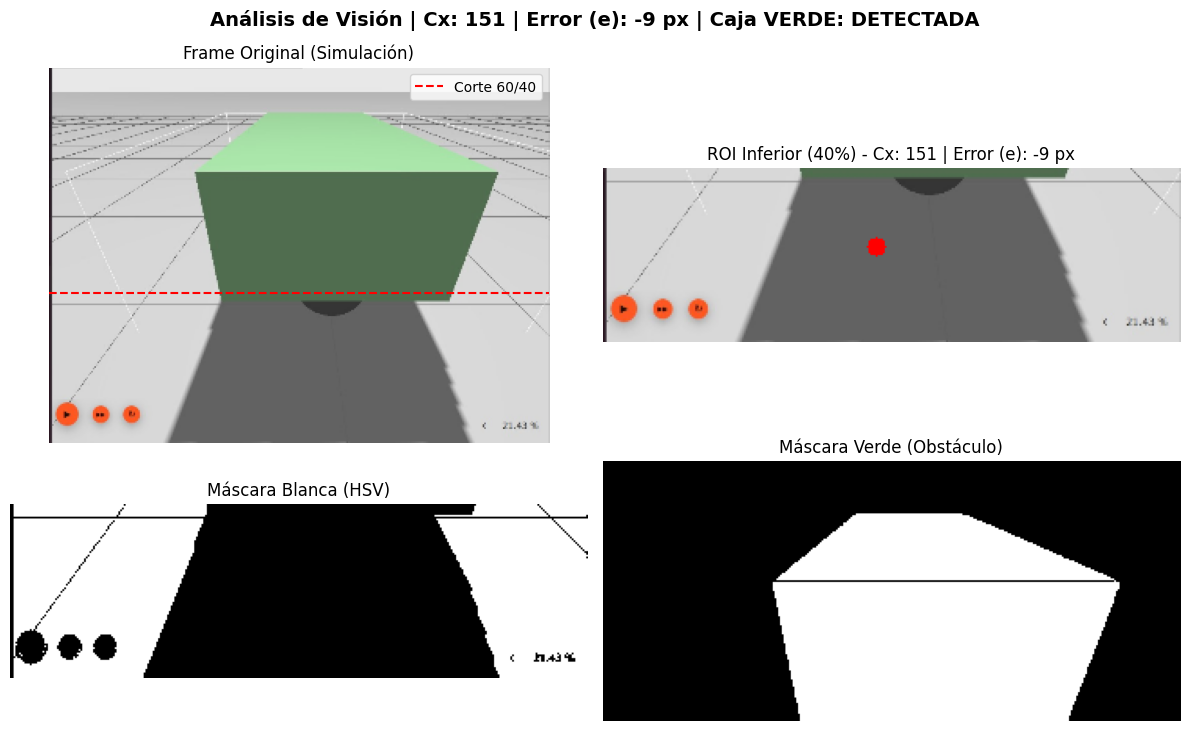

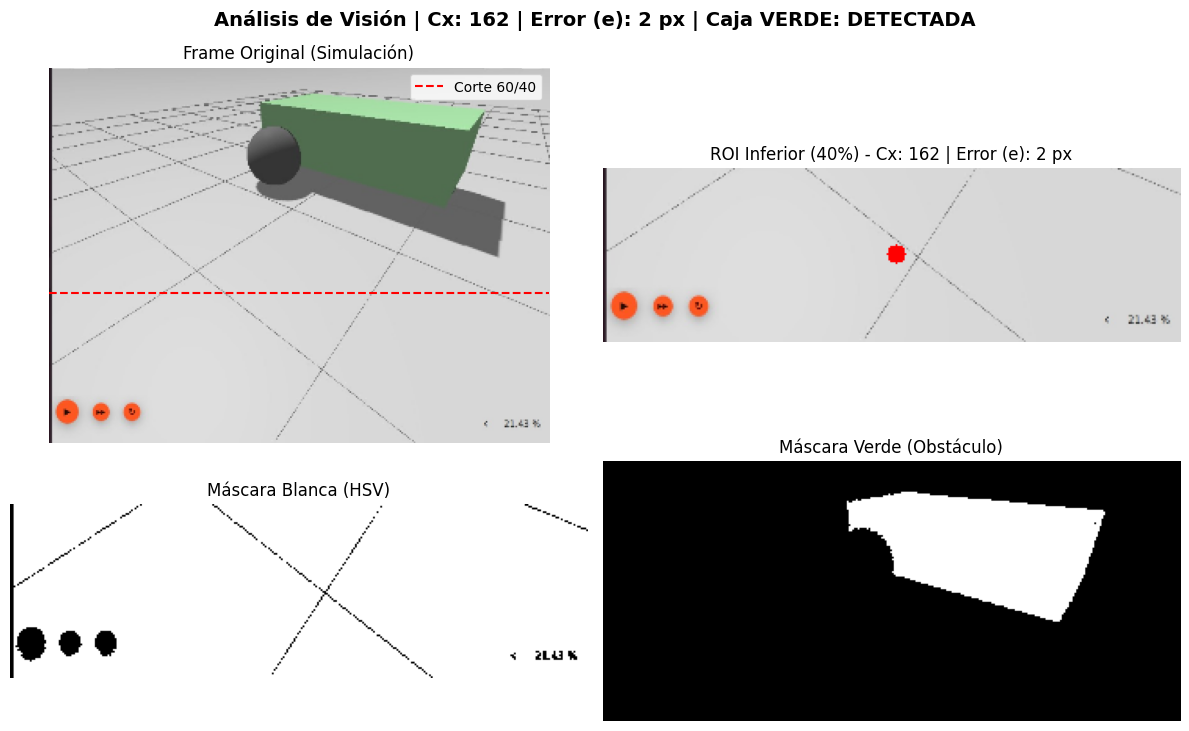

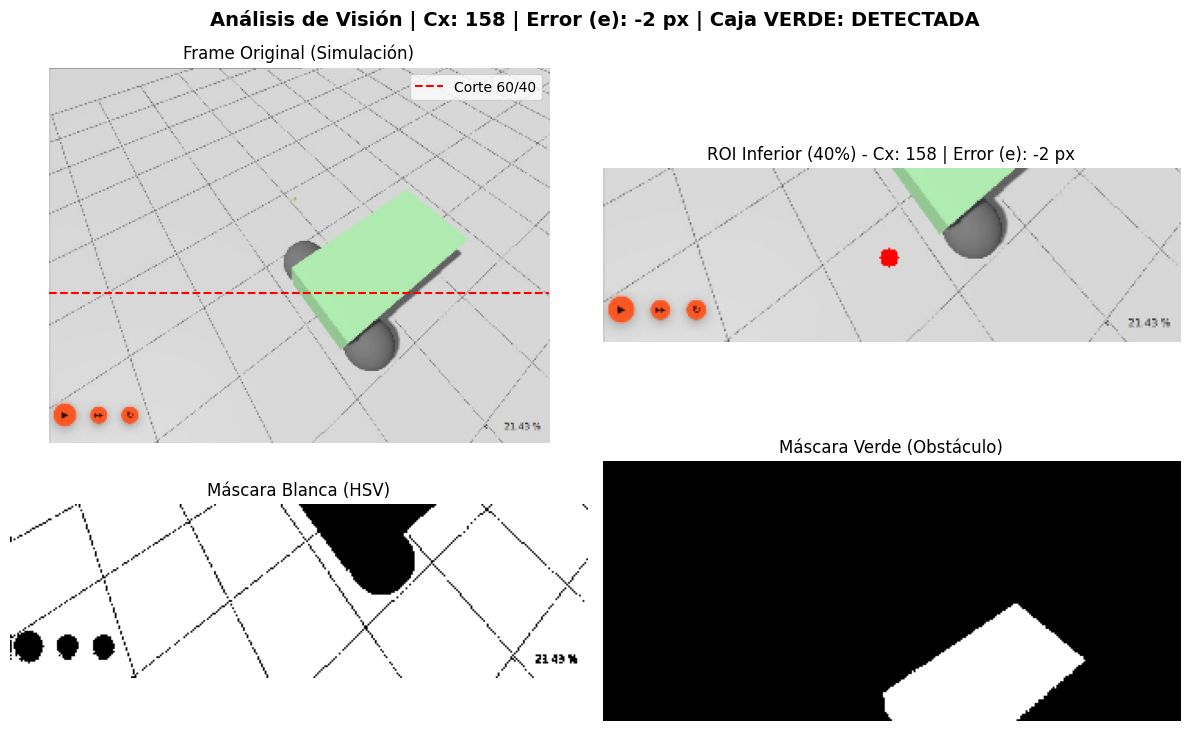

In [24]:
rutas_imagenes = sorted(glob.glob('Dataset_robot_verde/*.jpeg'))

if len(rutas_imagenes) == 0:
    print("No se encontraron imágenes. Verifica la ruta de la carpeta Dataset_robot_verde.")
else:
    print(f"Se encontraron {len(rutas_imagenes)} imágenes. Procesando muestra...")

    # Procesar las primeras 3 imágenes para la demostración del Notebook
    for ruta in rutas_imagenes[:3]:
        procesar_y_visualizar_frame(ruta)